In [1]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.pipeline import Pipeline                  # Combine preprocessing and models
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import mean_absolute_error

# PART 1 - Data Exploration and Data Cleaning / Preparation

In [2]:
#reading in dataset
ds = pd.read_csv('abalone.csv')
ds

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4175,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4176,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4177,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4178,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [3]:
#checking head
ds.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [4]:
#checking tail
ds.tail()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
4175,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4176,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4177,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4178,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10
4179,M,0.710,0.555,0.195,1.9485,0.9455,0.3765,0.4950,12


In [5]:
#checking unique values for sex
ds['Sex'].unique()

array(['M', 'F', 'I'], dtype=object)

In [6]:
#checking the number of duplicates
ds.duplicated().sum()

np.int64(3)

In [7]:
#checking number of nulls in dataset
print(ds.isnull().sum())

Sex               0
Length            0
Diameter          0
Height            8
Whole_weight      0
Shucked_weight    5
Viscera_weight    5
Shell_weight      0
Rings             0
dtype: int64


In [8]:
#going to start cleaning
df = pd.DataFrame(ds)
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [9]:
df.shape

(4180, 9)

In [10]:
#dropping duplicates
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [11]:
#dropping nulls
df = df.dropna()
print(df.isnull().sum())

Sex               0
Length            0
Diameter          0
Height            0
Whole_weight      0
Shucked_weight    0
Viscera_weight    0
Shell_weight      0
Rings             0
dtype: int64


In [12]:
#now we create objects x and y to store the data and the target value. 
X = df.drop(['Sex'],axis=1)
y = df['Sex']

# Verify the split
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4161, 8)
y shape: (4161,)


# PART 2 - Using Decision Tree and Logistical Regression Models

In [14]:
#Use train_test_split() to split the dataset into 70% training and 30% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

# Verify split sizes
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (2912, 8)
Testing set size: (1249, 8)


In [15]:
#Train decision tree classification model using training data and predict the sex classes of unseen testing data
dt_model = DecisionTreeClassifier(criterion = 'gini', random_state = 42)

dt_model = dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)

print("First 10 predictions:", y_pred[:10])
print("First 10 actual labels:", y_test.values[:10])

First 10 predictions: ['F' 'M' 'F' 'M' 'F' 'M' 'I' 'M' 'I' 'F']
First 10 actual labels: ['I' 'F' 'F' 'F' 'M' 'I' 'I' 'M' 'M' 'M']


In [16]:
#Generate the classification report 
print("Classification Report for DT:\n")
print(classification_report(y_test, y_pred))

Classification Report for DT:

              precision    recall  f1-score   support

           F       0.39      0.39      0.39       383
           I       0.66      0.61      0.64       410
           M       0.42      0.45      0.43       456

    accuracy                           0.48      1249
   macro avg       0.49      0.48      0.49      1249
weighted avg       0.49      0.48      0.49      1249



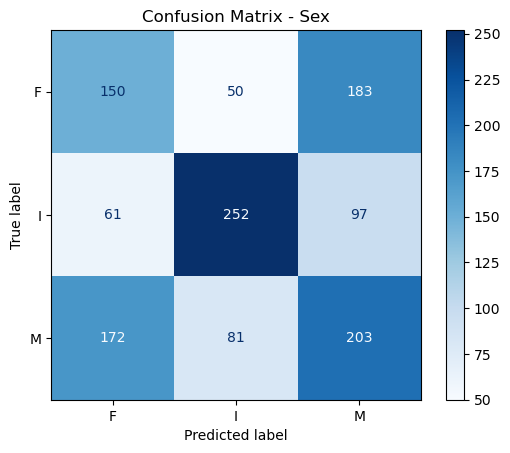

In [17]:
#confusion matrix of decision tree classification model
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = dt_model.classes_
)

disp.plot(cmap = "Blues", values_format = "d")
plt.title("Confusion Matrix - Sex")
plt.show()

In [18]:
#above model performs rather poorly. Going to try Logistic Regression next
#logistic regression can't work with categorical values like M,F,I , so need to label them using numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [19]:
#Use train_test_split() to split the dataset into 70% training and 30% testing
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size = 0.3, random_state = 42)

# Verify split sizes
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (2912, 8)
Testing set size: (1249, 8)


In [20]:
#Train logistical regression classification model using training data and predict the sex classes of unseen testing data
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train,y_train)
y_pred = lr_model.predict(X_test)

print("First 10 predictions:", y_pred[:10])
print("First 10 actual labels:", y_test[:10])

First 10 predictions: [1 2 0 2 0 1 0 2 1 2]
First 10 actual labels: [1 0 0 0 2 1 1 2 2 2]


In [21]:
#Generate the classification report
print("Classification Report for LR:\n")
print(classification_report(y_test, y_pred))

Classification Report for LR:

              precision    recall  f1-score   support

           0       0.48      0.33      0.39       383
           1       0.68      0.79      0.73       410
           2       0.47      0.53      0.50       456

    accuracy                           0.55      1249
   macro avg       0.54      0.55      0.54      1249
weighted avg       0.54      0.55      0.54      1249



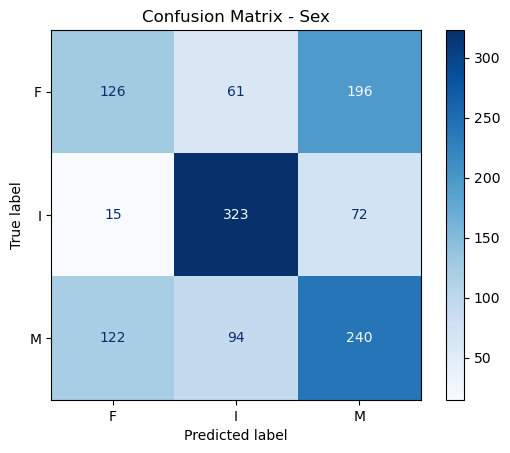

In [22]:
#confusion matrix of logistical regression classification model
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = dt_model.classes_
)

disp.plot(cmap = "Blues", values_format = "d")
plt.title("Confusion Matrix - Sex")
plt.show()